# Étape 2 — Prétraitement et extraction des features

**Objectif** : transformer chaque image en un vecteur de 2048 nombres (embedding) grâce à un ResNet-50 pré-entraîné sur ImageNet, et sauvegarder ces vecteurs pour l'étape 3 (clustering).

### Chargement de ResNet, modèle pré-entrainé

In [1]:
import torch
from torchvision import models

# Les poids appris sur ImageNet ("DEFAULT" = la meilleure version disponible)
poids = models.ResNet50_Weights.DEFAULT

# Le modèle ResNet-50, avec ces poids pré-entraînés
modele = models.resnet50(weights=poids)

print(modele)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

La dernière couche du réseau `(fc)`est intéressante, on a :
- 2048 features en entrée, les caractéristiques pertinentes pour classifier l'image
- 1000 sorties, les prédictions de ResNet-50 sur 1000 objets du quotidien (un score par classe d'ImageNet)

In [2]:
nb_parametres = sum(p.numel() for p in modele.parameters())
print(f"Nombre de paramètres : {nb_parametres:,}")

Nombre de paramètres : 25,557,032


Environ 25 millions de paramètres : impossible d'entrainer ce modèle depuis zéro avec nos 99 images labellisées

On va ensuite couper la tête du réseau ; remplacer la dernière couche qui prédisait les objets du quotidien (1000 sorties) par une couche qui ne fait rien

In [3]:
# On remplace la dernière couche par une couche qui ne fait... rien
modele.fc = torch.nn.Identity()

# Mode "évaluation" : on utilise le réseau, on ne l'entraîne pas
modele.eval()

print(modele.fc)


Identity()


Testons maintenant avec une fausse image

In [4]:
fausse_image = torch.randn(1, 3, 224, 224)   # 1 image, 3 canaux, 224×224 pixels

with torch.no_grad():
    sortie = modele(fausse_image)

print("Forme de l'entrée :", fausse_image.shape)
print("Forme de la sortie :", sortie.shape)


Forme de l'entrée : torch.Size([1, 3, 224, 224])
Forme de la sortie : torch.Size([1, 2048])


On obtient 2048 nombres qui représentent les features de l'image, son résumé (1 représente le nombre d'images du lot).

### 2.2 Pré-traiter une vraie IRM

Repartons des 1410 images sans doublons, fichier sauvegardé en fin d'étape 1.

In [5]:
import pandas as pd

inventaire = pd.read_csv("../data/inventaire.csv")
print(len(inventaire), "images")
inventaire.value_counts(["source", "label"], dropna=False)

1410 images


source       label 
sans_label   NaN       1311
avec_labels  cancer      50
             normal      49
Name: count, dtype: int64

Appliquons les transformations pour que nos images soient au format ResNet;
- on doit les passer en taille 224 x 224 pixels.
- on doit les convertir en tenseur PyTorch
- et on doit appliquer la normalisation d'ImageNet (constantes connues)

In [6]:
from torchvision import transforms

pretraitement = transforms.Compose([
    transforms.Resize((224, 224)),                      # 1) taille attendue par ResNet
    transforms.ToTensor(),                              # 2) image PIL -> tenseur PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # 3) normalisation ImageNet
                         std=[0.229, 0.224, 0.225]),
])


Appliquons le pré-traitement à une image

In [7]:
from PIL import Image

image = Image.open(inventaire["chemin"].iloc[0]).convert("RGB")
tenseur = pretraitement(image)

print("Avant  : taille", image.size, "| mode", image.mode)
print("Après  : forme", tuple(tenseur.shape))
print("Valeurs: min", round(tenseur.min().item(), 2), "| max", round(tenseur.max().item(), 2))
print("Moyenne par canal :", tenseur.mean(dim=(1, 2)))


Avant  : taille (512, 512) | mode RGB
Après  : forme (3, 224, 224)
Valeurs: min -2.12 | max 2.27
Moyenne par canal : tensor([-1.0513, -0.9453, -0.7189])


Observations :
- On note la valeur minimum -2.12. Hors un pixel noir vaut 0, et si on le normalise on obtient ; (0 − 0,485) / 0,229  =  −2,12 --> on retombe sur le bon chiffre
- Les moyennes sont toutes négatives, l'IRM est beaucoup plus sombre qu'une photo moyenne d'ImageNet (logique ; grand fond noir, cerveau au milieu vs photos de la vie courante, lumineuses et colorées)

Regardons ce que le réseau reçoit

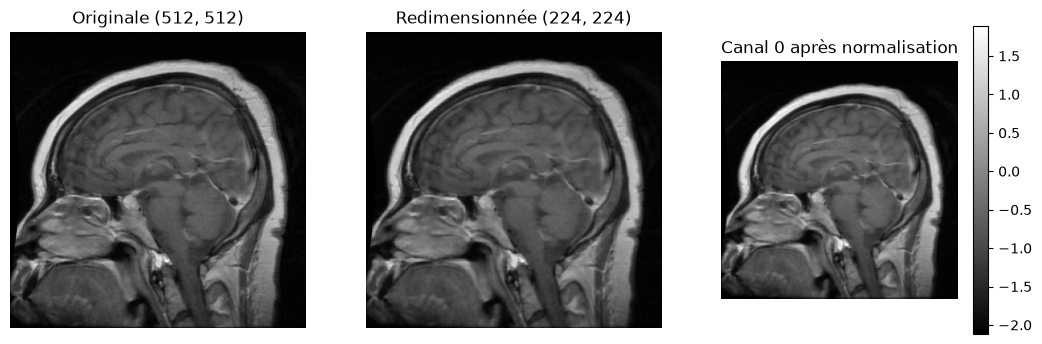

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(image)
axes[0].set_title(f"Originale {image.size}")

axes[1].imshow(image.resize((224, 224)))
axes[1].set_title("Redimensionnée (224, 224)")

carte = axes[2].imshow(tenseur[0], cmap="gray")   # canal 0 du tenseur normalisé
axes[2].set_title("Canal 0 après normalisation")
plt.colorbar(carte, ax=axes[2])                    # barre d'échelle des valeurs

for ax in axes:
    ax.axis("off")
plt.show()


Les 3 images se ressemblent fortement, je ne saurais les distinguer, ce qui est bon signe. Le seul vrai changement est la résolution, 224 x 224 au lieu de 512 x 512, les détails sont donc un peu plus flou.

Risque ; louper les petites tumeurs.

### 2.3 Extraction des embeddings

On ne peut pas envoyer les 1410 images au réseau d'un seul coup (trop lourd en mémoire) : on les traite **par lots**. PyTorch organise cela avec deux outils :
- un **`Dataset`** : sait ouvrir et prétraiter l'image n°i, à la demande ;
- un **`DataLoader`** : regroupe les images par lots de 32 et les envoie au modèle.

On crée notre propre classe `ImagesIRM`, qui hérite du `Dataset` de PyTorch. Les images ne sont ouvertes qu'au moment où on en a besoin, ce qui garde une consommation mémoire faible, indispensable pour un passage à l'échelle (4 millions d'images).

In [9]:
from torch.utils.data import Dataset, DataLoader


class ImagesIRM(Dataset):
    """Jeu d'images IRM : renvoie le tenseur prétraité de chaque image."""

    def __init__(self, chemins, transform):
        self.chemins = list(chemins)   # on mémorise la liste des chemins
        self.transform = transform     # et le prétraitement à appliquer

    def __len__(self):
        return len(self.chemins)

    def __getitem__(self, i):
        image = Image.open(self.chemins[i]).convert("RGB")
        return self.transform(image)


dataset = ImagesIRM(inventaire["chemin"], pretraitement)
print("Nombre d'images :", len(dataset))     # appelle __len__
print("Forme d'une image :", dataset[0].shape)   # appelle __getitem__(0)

Nombre d'images : 1410
Forme d'une image : torch.Size([3, 224, 224])


Le `DataLoader` regroupe les images par lots de 32. On garde `shuffle=False` : l'ordre des embeddings doit rester **identique** à celui de `inventaire.csv`, c'est ce qui permet d'associer chaque image à son vecteur.

In [10]:
chargeur = DataLoader(dataset, batch_size=32, shuffle=False)

premier_lot = next(iter(chargeur))   # on récupère juste le premier lot, pour vérifier
print("Forme d'un lot :", premier_lot.shape)
print("Nombre de lots :", len(chargeur))


Forme d'un lot : torch.Size([32, 3, 224, 224])
Nombre de lots : 45


On utilise le GPU du Mac (MPS) s'il est disponible, sinon une carte NVIDIA (CUDA), sinon le processeur (CPU). Le code reste ainsi portable d'une machine à l'autre.

In [11]:
if torch.backends.mps.is_available():
    appareil = torch.device("mps")    # GPU des Mac Apple Silicon (M1, M2, M3…)
elif torch.cuda.is_available():
    appareil = torch.device("cuda")   # carte graphique NVIDIA
else:
    appareil = torch.device("cpu")

modele = modele.to(appareil)          # on déplace le modèle sur cet appareil
print("Appareil utilisé :", appareil)


Appareil utilisé : mps


Extraction des embeddings : chaque lot passe dans ResNet-50 (sans sa dernière couche), en mode évaluation et sans calcul de gradients (`torch.no_grad()`) : les poids du réseau sont **gelés**, il n'y a aucun entraînement.

In [12]:
import numpy as np
from tqdm.auto import tqdm

morceaux = []   # on y rangera les embeddings, lot par lot

with torch.no_grad():                        # pas d'entraînement : couches gelées
    for lot in tqdm(chargeur, desc="Extraction"):
        lot = lot.to(appareil)               # les images doivent être sur le même appareil que le modèle
        sortie = modele(lot)                 # (32, 2048)
        morceaux.append(sortie.cpu().numpy())   # retour sur le processeur, puis conversion en numpy

embeddings = np.concatenate(morceaux)        # on recolle tous les morceaux les uns sous les autres
print("Forme finale :", embeddings.shape)


/Users/matthieu/dev/openclassrooms/projet7/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extraction: 100%|██████████| 45/45 [00:15<00:00,  2.85it/s]

Forme finale : (1410, 2048)


- 1410 images / 32 par lot = 44 lots complets + 1 dernier lot de 2 images, soit **45 lots**.
- Résultat : un tableau de **1410 × 2048** : une ligne par image, 2048 features par image.
- Toutes les valeurs sont **positives ou nulles** : la dernière couche avant `avgpool` est une ReLU (`max(0, x)`), qui remplace les valeurs négatives par 0, et `avgpool` fait la moyenne de ces valeurs positives.
- Environ 45 % des valeurs sont exactement nulles : de nombreux détecteurs appris sur des photos du quotidien ne réagissent pas aux IRM.

Sauvegarde des embeddings. **Important** : la ligne i de `embeddings.npy` correspond à la ligne i de `inventaire.csv`. À l'étape 3, on chargera les deux fichiers ensemble.

In [13]:
np.save("../data/embeddings.npy", embeddings)
print("Embeddings sauvegardés :", embeddings.shape)

Embeddings sauvegardés : (1410, 2048)


## Conclusion de l'étape 2

| Point | Choix / résultat |
|---|---|
| Modèle | ResNet-50 pré-entraîné sur ImageNet, dernière couche (`fc`) remplacée par `Identity` |
| Gel des couches | mode `eval()` + `torch.no_grad()` : aucun poids modifié, aucun entraînement |
| Prétraitement | redimensionnement 224×224, conversion en tenseur, normalisation avec les moyennes et écarts-types d'ImageNet |
| Chargement | classe `ImagesIRM` (Dataset) + `DataLoader` par lots de 32, sans mélange pour conserver l'ordre |
| Résultat | **1410 embeddings de 2048 features**, sauvegardés dans `data/embeddings.npy` (même ordre que `data/inventaire.csv`) |

**Limites identifiées**
- Le passage de 512×512 à 224×224 peut faire perdre les détails des petites tumeurs.
- ResNet a appris sur des photos du quotidien, très différentes des IRM (images plus sombres, en niveaux de gris) : les embeddings ne sont pas spécialisés pour l'imagerie médicale.

**Piste si le clustering de l'étape 3 est décevant** : extraire les features d'une couche plus précoce de ResNet, ou garder une résolution plus élevée.